# Аналитическое исследование рынка видеоигр за период 2000–2013 гг.


- Автор: Омурбеков Марс
- Дата: 22.12.2025

## Цели и задачи проекта

В данной тетрадке используется датасет `/datasets/new_games.csv`. В датасете собраны исторические данные о продажах видеоигр, выпущенных на различных платформах и в разных жанрах, а также пользовательские и экспертные оценки игр.

Цель проекта — выполнить предобработку данных и провести исследовательский анализ рынка видеоигр за период 2000–2013 гг., изучив популярность игровых платформ, жанров и распределение продаж по регионам.

### Описание данных

Данные `/datasets/new_games.csv` содержат информацию о продажах игр разных жанров и платформ, а также пользовательские и экспертные оценки игр.

- **Name** — название игры  
- **Platform** — название платформы  
- **Year of Release** — год выпуска игры  
- **Genre** — жанр игры  
- **NA sales** — продажи в Северной Америке (в миллионах проданных копий)  
- **EU sales** — продажи в Европе (в миллионах проданных копий)  
- **JP sales** — продажи в Японии (в миллионах проданных копий)  
- **Other sales** — продажи в других странах (в миллионах проданных копий)  
- **Critic Score** — оценка критиков (от 0 до 100)  
- **User Score** — оценка пользователей (от 0 до 10)  
- **Rating** — рейтинг организации ESRB (Entertainment Software Rating Board), определяющий возрастную категорию игры


### Содержание проекта

1. Загрузка и знакомство с данными 
2. Проверка ошибок в данных и предобработка 
3. Фильтрация данных 
4. Категоризация данных
5. Исследовательский анализ данных
6. Итоговый вывод

---

In [ ]:
# Импортируем библиотеки 
import pandas as pd
import matplotlib.pyplot as plt

## 1. Загрузка данных и знакомство с ними

- Загрузим необходимые библиотеки Python и данные датасета `/datasets/new_games.csv`.

In [66]:
# Выгружаем данные из датасета /datasets/new_games.csv в датафрейм games  
games = pd.read_csv('https://code.s3.yandex.net/datasets/new_games.csv')

- Познакомимся с данными: выведем первые строки и результат метода `info()`.


In [67]:
# Выводим информацию о датафрейме
games.info()

<class 'pandas.DataFrame'>
RangeIndex: 16956 entries, 0 to 16955
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16954 non-null  str    
 1   Platform         16956 non-null  str    
 2   Year of Release  16681 non-null  float64
 3   Genre            16954 non-null  str    
 4   NA sales         16956 non-null  float64
 5   EU sales         16956 non-null  str    
 6   JP sales         16956 non-null  str    
 7   Other sales      16956 non-null  float64
 8   Critic Score     8242 non-null   float64
 9   User Score       10152 non-null  str    
 10  Rating           10085 non-null  str    
dtypes: float64(4), str(7)
memory usage: 1.4 MB


In [68]:
games.head()

,Name,Platform,Year of Release,Genre,NA sales,EU sales,JP sales,Other sales,Critic Score,User Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [69]:
games.tail()

,Name,Platform,Year of Release,Genre,NA sales,EU sales,JP sales,Other sales,Critic Score,User Score,Rating
16951,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.0,0.01,0.0,NaN,NaN,NaN
16952,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.0,0.0,NaN,NaN,NaN
16953,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.0,0.01,0.0,NaN,NaN,NaN
16954,Spirits & Spells,GBA,2003.0,Platform,0.01,0.0,0.0,0.0,NaN,NaN,NaN
16955,Winning Post 8 2016,PSV,2016.0,Simulation,0.00,0.0,0.01,0.0,NaN,NaN,NaN


In [70]:
games.describe()

,Year of Release,NA sales,Other sales,Critic Score
count,16681.000000,16956.000000,16956.000000,8242.000000
mean,2006.485522,0.262023,0.047087,68.926717
std,5.873102,0.808654,0.185577,13.944565
min,1980.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.010000,71.000000
75%,2010.000000,0.240000,0.030000,79.000000
max,2016.000000,41.360000,10.570000,98.000000


Датасет `/datasets/new_games.csv` содержит 11 столбцов и 1956 строк.

Изучим типы данных и их корректность:

- **Числовые значения с плавающей запятой (`float64`).**  
  В датасете несколько столбцов имеют тип данных `float64`:

  - `Year of Release` содержит информацию о годе выпуска игр. Для работы с данными может быть рассмотрено преобразование в тип `int`, что упростит анализ.
  
  - `NA sales` и `Other sales` содержат данные о продажах в Северной Америке и других странах (в миллионах проданных копий). Использование числового типа данных является корректным, так как значения могут быть дробными.
  
  - `Critic Score` содержит оценки критиков в диапазоне от 0 до 100 и представлен числовым типом данных, что соответствует характеру данных.


- **Строковые данные (`object`).**  
  В датасете несколько столбцов имеют тип данных `object`:

  - `Name`, `Platform` и `Genre` содержат строковую информацию (название игры, название платформы, жанр игры), поэтому тип `object` здесь корректен.
  
  - `EU sales`, `JP sales` и `User Score` на самом деле содержат числовые данные (продажи в миллионах копий и оценки пользователей) и должны быть приведены к типу `float64`.
  
  - `Rating` хранит текстовые данные, но его можно рассматривать как категориальный признак. Использование типа `category` позволит оптимизировать память и повысить производительность при анализе.



Первичный анализ показал, что большинство столбцов имеют корректные типы данных. Вместе с тем отдельные столбцы требуют преобразования типов для обеспечения корректности последующего анализа. Кроме того, названия столбцов следует привести к единому стилю snake_case, что повысит читаемость кода и соответствует общепринятым рекомендациям.


---

## 2. Предобработка данных

### 2.1. Стандартизация названий столбцов

На данном этапе проверяются названия столбцов датасета. При необходимости они приводятся к единому формату `snake_case`, что повышает читаемость кода и соответствует рекомендациям PEP 8.

In [71]:
games.columns

Index(['Name', 'Platform', 'Year of Release', 'Genre', 'NA sales', 'EU sales',
       'JP sales', 'Other sales', 'Critic Score', 'User Score', 'Rating'],
      dtype='str')

In [72]:
# Приводим названия столбцов к нижнему регистру и меняем пробелы на подчеркивание
games.columns = games.columns.str.lower().str.replace(' ', '_')

In [73]:
games.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='str')

---

### 2.2. Анализ и преобразование типов данных

#### 2.2.1. Столбцы `eu_sales`, `jp_sales`, `user_score`

Столбцы должны содержать числовые значения, однако Pandas определил их как строковый тип данных (object). Перед преобразованием необходимо убедиться, что в столбцах отсутствуют некорректные текстовые значения, которые могут привести к появлению пропусков после конвертации.

Для этого была разработана небольшая вспомогательная функция, которая анализирует содержимое столбца, определяет значения, не поддающиеся преобразованию в числовой формат, и выводит краткий отчёт. Такой подход позволяет сначала исследовать данные, а затем осознанно принять решение об их преобразовании.

In [74]:
def find_invalid_numeric_values(df, column): 
    convert = pd.to_numeric(df[column], errors='coerce')
    mask = convert.isna() & df[column].notna()
    result = df.loc[mask, column]
    print(f"Тип данных: {df[column].dtype}")
    print('-' * 100)
    print(f"Некорректных записей: {len(result)}")
    print('-' * 100)
    print(f"Значения в столбце: {result.value_counts().to_string()}")
    print('-' * 100)

In [75]:
find_invalid_numeric_values(games, 'eu_sales')

Тип данных: str
----------------------------------------------------------------------------------------------------
Некорректных записей: 6
----------------------------------------------------------------------------------------------------
Значения в столбце: eu_sales
unknown    6
----------------------------------------------------------------------------------------------------


In [76]:
find_invalid_numeric_values(games, 'jp_sales')

Тип данных: str
----------------------------------------------------------------------------------------------------
Некорректных записей: 4
----------------------------------------------------------------------------------------------------
Значения в столбце: jp_sales
unknown    4
----------------------------------------------------------------------------------------------------


In [77]:
find_invalid_numeric_values(games, 'user_score')

Тип данных: str
----------------------------------------------------------------------------------------------------
Некорректных записей: 2464
----------------------------------------------------------------------------------------------------
Значения в столбце: user_score
tbd    2464
----------------------------------------------------------------------------------------------------


Проверка показала, что единственными некорректными значениями являются текстовые метки unknown и tbd. Это позволяет безопасно преобразовать столбцы в числовой тип float, при этом такие значения будут автоматически заменены на NaN.

In [78]:
columns = [
    'eu_sales',
    'jp_sales',
    'user_score'
]

for column in columns:
    games[column] = pd.to_numeric(games[column], errors='coerce')

In [79]:
games[['eu_sales', 'jp_sales', 'user_score']].dtypes

eu_sales      float64
jp_sales      float64
user_score    float64
dtype: object

По результатам проверки столбцы были приведены к типу данных float. Значения, не поддающиеся преобразованию в числовой формат, были заменены на NaN. Такой подход обеспечивает корректную работу с числовыми данными и позволяет учитывать проблемные записи на последующих этапах анализа.

---

#### 2.2.2. Столбец `year_of_release`

Год выпуска является целочисленным значением, поэтому необходимо привести столбец к соответствующему типу данных.
Перед изменением типа данных необходимо проверить наличие пропущенных значений, так как стандартный тип int их не поддерживает.

In [80]:
games['year_of_release'].isna().sum()

np.int64(275)

In [81]:
games['year_of_release'] = games['year_of_release'].astype('Int64')

print(f"Тип данных: {games['year_of_release'].dtype}")

Тип данных: Int64


В столбце обнаружены пропущенные значения. Использование стандартного типа `int` невозможно, поскольку он не поддерживает `NaN`. Поэтому столбец был приведён к типу `Int64`, который позволяет хранить целые значения и корректно работать с пропусками.

---

#### 2.2.3. Столбец `rating`

Рейтинг ESRB содержит ограниченный набор категорий, поэтому использование типа `category` является более подходящим.

In [82]:
games['rating'] = games['rating'].astype('category')

print(games['rating'].unique())

['E', NaN, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP']
Categories (8, str): ['AO', 'E', 'E10+', 'EC', 'K-A', 'M', 'RP', 'T']


Тип изменён на category, что позволяет уменьшить потребление памяти и повысить эффективность обработки.

---

### 2.3. Анализ пропусков

- Посчитаем количество пропусков в каждом столбце в абсолютных и относительных значениях.


In [83]:
# Количество пропусков в каждом столбце (абсолютно)
games.isna().sum()

name                  2
platform              0
year_of_release     275
genre                 2
na_sales              0
eu_sales              6
jp_sales              4
other_sales           0
critic_score       8714
user_score         9268
rating             6871
dtype: int64

In [84]:
# Доля пропусков в каждом столбце (относительно всего столбца)
games.isna().mean() * 100

name                0.011795
platform            0.000000
year_of_release     1.621845
genre               0.011795
na_sales            0.000000
eu_sales            0.035386
jp_sales            0.023590
other_sales         0.000000
critic_score       51.391838
user_score         54.659118
rating             40.522529
dtype: float64

##### Вывод

- Доля пропусков в столбцах `name`, `genre` и `year_of_release` не превышает 2%. В связи с небольшим количеством таких записей они были удалены, поскольку их исключение не должно оказать существенного влияния на результаты исследования.

- В столбцах `critic_score` (8714 пропусков, 51.4%), `user_score` (9268 пропусков, 54.7%) и `rating` (6871 пропуск, 40.5%) пропуски встречаются часто. Высокая доля пропусков объясняется тем, что оценки пользователей, критиков и рейтинг ESRB доступны не для всех игр, особенно для более старых релизов.

- Остальные столбцы с продажами (`na_sales, eu_sales, jp_sales, other_sales`) пропусков не содержат.

**Вывод:** большинство пропусков сосредоточено в столбцах с оценками критиков и пользователей, а также в рейтинге ESRB. Для анализа продаж эти пропуски не критичны, но для работы с оценками игр их потребуется обработать или учитывать.

---

#### 2.3.1. Обработка пропусков 

##### Пропуски в столбце `name`, `genre` и `year_of_release`

In [85]:
games = games.dropna(subset=['name', 'genre', 'year_of_release'])

# После удаления
games[['name', 'genre', 'year_of_release']].isna().sum()

name               0
genre              0
year_of_release    0
dtype: int64

##### Вывод
Небольшое количество пропусков в столбцах `name`, `genre` и `year_of_release` было удалено, так как их доля не превышает 2% и это не окажет существенного влияния на результаты исследования. Пропуски в `critic_score`, `user_score` и `rating сохранены`, поскольку они составляют значительную часть данных и могут отражать отсутствие оценок, а не ошибку в данных.

---

### 2.4.  Анализ неявных дубликатов

#### 2.4.1. Изучение уникальных значений

- Изучим уникальные значения в категориальных данных, например с названиями жанра игры, платформы, рейтинга и года выпуска. Проверим, встречаются ли среди данных неявные дубликаты, связанные с опечатками или разным способом написания.
- При необходимости проводим нормализацию данных с текстовыми значениями. Названия или жанры игр можно привести к нижнему регистру, а названия рейтинга — к верхнему.

In [86]:
print("Количество уникальных значений:")
print(f"Жанры: {games['genre'].nunique()}")
print(f"Платформы: {games['platform'].nunique()}")
print(f"Рейтинги: {games['rating'].nunique()}")
print(f"Годы выпуска: {games['year_of_release'].nunique()}")

Количество уникальных значений:
Жанры: 24
Платформы: 31
Рейтинги: 8
Годы выпуска: 37


In [87]:
display(games['genre'].value_counts())

display(games['platform'].value_counts())

display(games['rating'].value_counts())

genre
Action          3341
Sports          2325
Misc            1740
Role-Playing    1493
Shooter         1314
Adventure       1309
Racing          1244
Platform         891
Simulation       866
Fighting         844
Strategy         679
Puzzle           577
ACTION            12
SPORTS             7
ROLE-PLAYING       6
RACING             6
FIGHTING           6
SHOOTER            5
ADVENTURE          4
MISC               3
PLATFORM           3
PUZZLE             2
SIMULATION         1
STRATEGY           1
Name: count, dtype: int64

platform
PS2     2154
DS      2147
PS3     1330
Wii     1305
X360    1249
PSP     1212
PS      1208
PC       972
GBA      826
XB       818
GC       549
3DS      522
PSV      434
PS4      395
N64      320
XOne     251
SNES     241
SAT      174
WiiU     147
2600     118
NES      100
GB        97
DC        52
GEN       27
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: count, dtype: int64

rating
E       3968
T       2948
M       1558
E10+    1414
EC         8
K-A        3
AO         1
RP         1
Name: count, dtype: int64

In [88]:
# Проверка на пробелы 

print("Лишние пробелы в genre:",
      (games['genre'] != games['genre'].str.strip()).sum())

print("Лишние пробелы в platform:",
      (games['platform'] != games['platform'].str.strip()).sum())

print("Лишние пробелы в rating:",
      games['rating'].dropna().ne(games['rating'].dropna().str.strip()).sum())

Лишние пробелы в genre: 0
Лишние пробелы в platform: 0
Лишние пробелы в rating: 0


---

#### 2.4.2. Нормализация данных

In [89]:
# Удаляем пробелы
games['genre'] = games['genre'].str.strip()
games['platform'] = games['platform'].str.strip()
games['rating'] = games['rating'].str.strip()
games['name'] = games['name'].str.strip()

# Приводим к нужному регистру
games['genre'] = games['genre'].str.lower()
games['name'] = games['name'].str.lower()
games['rating'] = games['rating'].str.upper()

In [90]:
print("\nПОСЛЕ НОРМАЛИЗАЦИИ:")
print(f"Жанры: {games['genre'].nunique()}")
print(f"Платформы: {games['platform'].nunique()}")
print(f"Рейтинги: {games['rating'].nunique()}")

print("\nУникальные жанры после нормализации:")
print(games['genre'].unique())


ПОСЛЕ НОРМАЛИЗАЦИИ:
Жанры: 12
Платформы: 31
Рейтинги: 8

Уникальные жанры после нормализации:
<StringArray>
[      'sports',     'platform',       'racing', 'role-playing',
       'puzzle',         'misc',      'shooter',   'simulation',
       'action',     'fighting',    'adventure',     'strategy']
Length: 12, dtype: str


##### Вывод
До нормализации в столбце genre было обнаружено 24 уникальных значения. После приведения регистра их количество сократилось до 12, что подтверждает наличие неявных дубликатов, вызванных различием регистра (например, Action и ACTION, Sports и SPORTS). Проверка не выявила лишних пробелов в категориальных столбцах, поэтому для обеспечения единообразия данные были очищены методом .strip(), а текстовые значения приведены к единому регистру.

---

### 2.5. Анализ явных дубликатов

#### 2.5.1. Поиск явных дубликатов

In [91]:
# Проверка полных дубликатов
print(f"Дубликатов: {games.duplicated().sum()}")

Дубликатов: 235


In [92]:
# Смотрим какие строки дублируются
if games.duplicated().sum() > 0:
    print("\nПримеры дубликатов:")
    duplicates = games[games.duplicated(keep=False)].sort_values('name')
    print(duplicates.head(10))


Примеры дубликатов:
                                            name platform  year_of_release  \
15301                          11eyes: crossover     X360             2009   
15302                          11eyes: crossover     X360             2009   
4861            18 wheeler: american pro trucker      PS2             2001   
4860            18 wheeler: american pro trucker      PS2             2001   
13099                                 4 elements       PC             2009   
13098                                 4 elements       PC             2009   
5235   999: nine hours, nine persons, nine doors       DS             2009   
5236   999: nine hours, nine persons, nine doors       DS             2009   
4959                              alpha protocol     X360             2010   
4958                              alpha protocol     X360             2010   

              genre  na_sales  eu_sales  jp_sales  other_sales  critic_score  \
15301     adventure      0.00      0.00 

In [93]:
# Удаляем дубликаты
rows_before = len(games)
games = games.drop_duplicates()
rows_after = len(games)

In [94]:
# Подсчет удаленных данных
total_removed = rows_before - rows_after
percent_removed = (total_removed / rows_before) * 100

print("Результаты удаления явных дубликатов")
print("-" * 100)
print(f"Количество строк после обработки пропусков: {rows_before}")
print(f"Удалено строк: {total_removed} ({percent_removed:.2f}%)")
print(f"Осталось строк: {rows_after} ({100 - percent_removed:.2f}%)")

Результаты удаления явных дубликатов
----------------------------------------------------------------------------------------------------
Количество строк после обработки пропусков: 16679
Удалено строк: 235 (1.41%)
Осталось строк: 16444 (98.59%)


---

### 2.6. Итоги предобработки

На этапе предобработки были выявлены и устранены основные проблемы качества данных. Названия столбцов приведены к единому стилю для повышения читаемости и удобства дальнейшей работы с датасетом.

В столбцах с годом выпуска, оценками критиков и пользователей пропущенные значения были сохранены, поскольку их удаление привело бы к существенной потере информации, а корректно восстановить такие данные невозможно. Две записи с отсутствующими названиями игр были удалены, так как они не представляют аналитической ценности.

Типы данных были приведены к корректному формату: год выпуска преобразован в целочисленный тип с поддержкой пропусков, оценки пользователей переведены в числовой формат, что позволяет использовать их в дальнейших расчетах.

При анализе категориальных признаков были обнаружены неявные дубликаты, вызванные различием регистра текстовых значений. После нормализации количество уникальных жанров сократилось с 24 до 12, при этом лишних пробелов в текстовых данных обнаружено не было.

Также были найдены и удалены 235 полностью идентичных строк, что составляет около 1,41% от объема данных после обработки пропусков. Были удалены. 

В результате датасет очищен от явных и неявных дубликатов, имеет корректные типы данных и согласованный формат категориальных признаков. Полученные данные готовы к дальнейшему исследовательскому анализу и проверке поставленных гипотез.

## 3. Фильтрация данных

Для дальнейшего анализа отберем данные за период с 2000 по 2013 год включительно и сохраним их в отдельный датафрейм `df_actual`.

In [95]:
# Фильтруем данные за период 2000-2013 гг. включительно
df_actual = games[(games['year_of_release'] >= 2000) & (games['year_of_release'] <= 2013)].copy()

# Проверим результат: минимальный и максимальный год в новом датасете
print(f"Минимальный год: {df_actual['year_of_release'].min()}")
print(f"Максимальный год: {df_actual['year_of_release'].max()}")
print(f"Количество строк в срезе: {len(df_actual)}")

Минимальный год: 2000
Максимальный год: 2013
Количество строк в срезе: 12781


## 4. Категоризация данных

### 4.1. Категоризация пользовательских оценок

Для дальнейшего анализа разделим игры по пользовательским оценкам на три категории:

- высокая оценка (от 8 до 10 включительно);
- средняя оценка (от 3 до 8, не включая 8);
- низкая оценка (от 0 до 3, не включая 3).

In [96]:
# Функция для категоризации
def categorize_user_score(score):
    if pd.isna(score):
        return 'отсутствует'
    if 8 <= score <= 10:
        return 'высокая оценка'
    if 3 <= score < 8:
        return 'средняя оценка'
    if 0 <= score < 3:
        return 'низкая оценка'
    return 'unknown'

In [97]:
# Применяем функцию к актуальному срезу данных
df_actual['user_score_category'] = df_actual['user_score'].apply(categorize_user_score)

### 4.2. Категоризация оценок критиков

Аналогичным образом выполним категоризацию оценок критиков:

- высокая оценка (от 80 до 100 включительно);
- средняя оценка (от 30 до 80, не включая 80);
- низкая оценка (от 0 до 30, не включая 30).

In [98]:
# Функция для категоризации оценок критиков
def categorize_critic_score(score):
    if pd.isna(score):
        return 'отсутствует'
    if 80 <= score <= 100:
        return 'высокая оценка'
    if 30 <= score < 80:
        return 'средняя оценка'
    if 0 <= score < 30:
        return 'низкая оценка'
    return 'unknown'

In [99]:
# Применяем функцию
df_actual['critic_score_category'] = df_actual['critic_score'].apply(categorize_critic_score)

### 4.3. Анализ результатов категоризации

In [100]:
# Проверяем распределение по категориям
print(df_actual['user_score_category'].value_counts())

user_score_category
отсутствует       6298
средняя оценка    4081
высокая оценка    2286
низкая оценка      116
Name: count, dtype: int64


##### Промежуточные выводы по пользовательским оценкам (`user_score_category`)

- **Преобладание отсутствующих оценок.**  
  Наибольшее количество игр относится к категории *«оценка отсутствует»* (6415 записей). Это указывает на значительную долю релизов, для которых пользовательская оценка либо не была сформирована, либо недоступна в исходных данных.

- **Смещение распределения в сторону положительных оценок.**  
  Среди игр с доступной пользовательской оценкой чаще всего встречается категория *«средняя оценка»* (4159), за которой следует *«высокая оценка»* (2328). Это может свидетельствовать о том, что большинство оценённых пользователями игр воспринимаются как как минимум удовлетворительные.

- **Низкая доля негативных оценок.**  
  Категория *«низкая оценка»* представлена минимальным количеством наблюдений (119). Это может быть связано как с меньшим числом действительно негативно воспринятых игр, так и с возможной склонностью пользователей реже оставлять оценки для неудачных проектов.

- **Ограничения анализа.**  
  Существенная доля отсутствующих пользовательских оценок снижает репрезентативность выводов о восприятии игр аудиторией и должна учитываться при дальнейшем анализе зависимости пользовательских оценок от продаж или других показателей.


In [101]:
# Проверяем распределение по критикам
print(df_actual['critic_score_category'].value_counts())

critic_score_category
отсутствует       5612
средняя оценка    5422
высокая оценка    1692
низкая оценка       55
Name: count, dtype: int64


#### Промежуточные выводы по оценкам критиков (`critic_score_category`)

- **Значительная доля отсутствующих оценок.**  
  Для существенной части игр оценки критиков отсутствуют (5703 записи). Это указывает на неполноту охвата критическими обзорами, особенно для менее известных или нишевых релизов.

- **Преобладание средней оценки среди доступных значений.**  
  Наиболее распространённой категорией среди игр с оценками является *«средняя оценка»* (5536). Это свидетельствует о том, что большинство проанализированных проектов получают сдержанно-положительные или нейтральные оценки со стороны профессиональных критиков.

- **Ограниченное количество высоко оценённых игр.**  
  Категория *«высокая оценка»* представлена значительно меньшим числом наблюдений (1724), что указывает на относительно редкое получение критически высоких оценок.

- **Минимальная доля низких оценок.**  
  Категория *«низкая оценка»* встречается крайне редко (58 случаев). Это может быть связано как с селективностью критических обзоров, так и с более жёсткими критериями включения игр в профессиональные рейтинги.

- **Выводы с учётом ограничений.**  
  Существенное количество пропусков в оценках критиков следует учитывать при анализе их влияния на коммерческий успех игр, так как это может ограничивать обобщаемость полученных результатов.


---

## 5. Исследовательский анализ данных

### 5.1. Наиболее популярные игровые платформы

In [102]:
# Считаем количество выпущенных игр для каждой платформы в актуальном периоде
top_7_platforms = df_actual.groupby('platform')['name'].count().sort_values(ascending=False).head(7)

In [103]:
print("Топ-7 платформ по количеству игр в период 2000-2013 гг.:")
print(top_7_platforms)

Топ-7 платформ по количеству игр в период 2000-2013 гг.:
platform
PS2     2127
DS      2120
Wii     1275
PSP     1180
X360    1121
PS3     1087
GBA      811
Name: name, dtype: int64


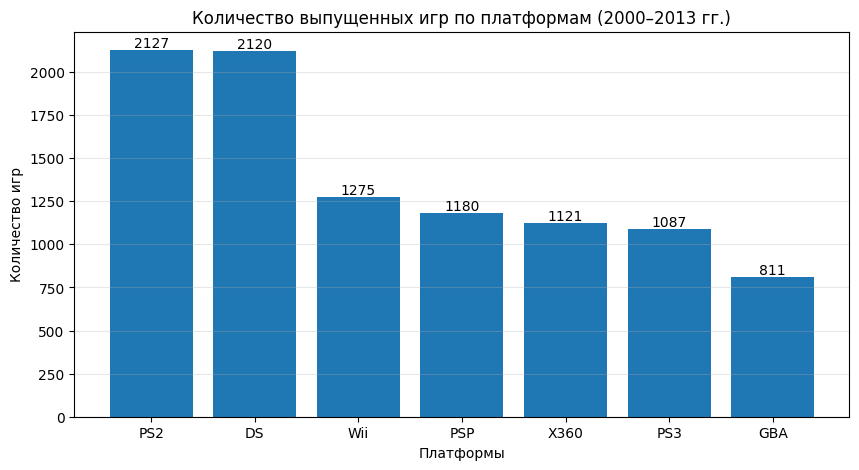

In [104]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    top_7_platforms.index,
    top_7_platforms.values
)

plt.title('Количество выпущенных игр по платформам (2000–2013 гг.)')
plt.xlabel('Платформы')
plt.ylabel('Количество игр')
plt.grid(axis='y', alpha=0.3 )
plt.bar_label(bars)

plt.show()

#### Вывод

В период с 2000 по 2013 год наибольшее количество игр было выпущено для платформ PS2 и DS. В число лидеров также вошли Wii, PSP, Xbox 360, PS3 и GBA. Среди семи платформ три принадлежат линейке PlayStation, а три являются портативными устройствами (DS, PSP, GBA), что отражает разнообразие лидеров рынка по количеству выпущенных игр.

---

### 5.2. Какие жанры выпускались чаще всего в период 2000–2013г.

In [114]:
top_5_genres = df_actual['genre'].value_counts().head()

top_5_genres

genre
action          2460
sports          1818
misc            1484
role-playing    1079
adventure       1009
Name: count, dtype: int64

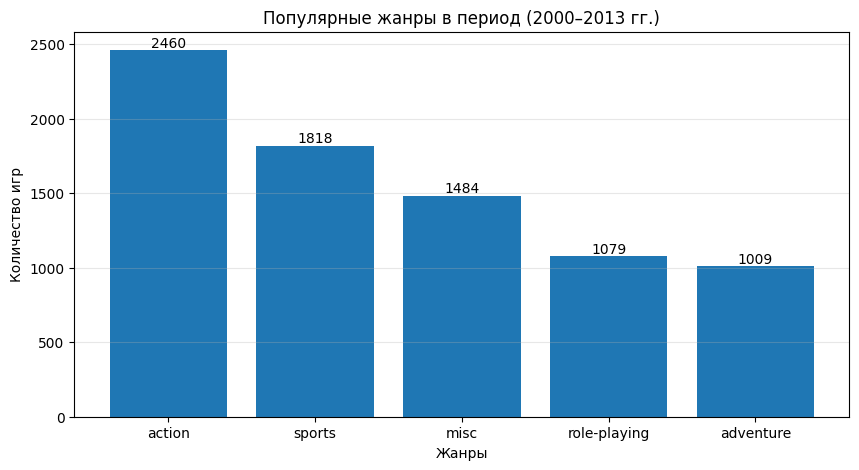

In [115]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    top_5_genres.index,
    top_5_genres.values
)

plt.title('Популярные жанры в период (2000–2013 гг.)')
plt.xlabel('Жанры')
plt.ylabel('Количество игр')
plt.grid(axis='y', alpha=0.3 )
plt.bar_label(bars)

plt.show()

#### Вывод

Наиболее популярным жанром оказался Action (2460 игр), что заметно превышает показатели остальных жанров. Второе место занимает Sports (1818 игр), а третье место приходится на категорию Misc, включающую различные игры, не вошедшие в основные жанровые группы.

----

### 5.3. Жанры с наибольшими мировыми продажами

In [126]:
df_actual["total_sales"] = (
    df_actual["na_sales"] +
    df_actual["eu_sales"] +
    df_actual["jp_sales"] +
    df_actual["other_sales"]
)

In [150]:
top_5_sales = (df_actual
    .groupby('genre')
    .agg({'total_sales': 'sum'})
    .sort_values(by='total_sales', ascending=False)
    .head()
    .reset_index()
)

top_5_sales

,genre,total_sales
0,action,1318.80
1,sports,1021.44
2,shooter,741.76
3,misc,676.28
4,role-playing,629.78


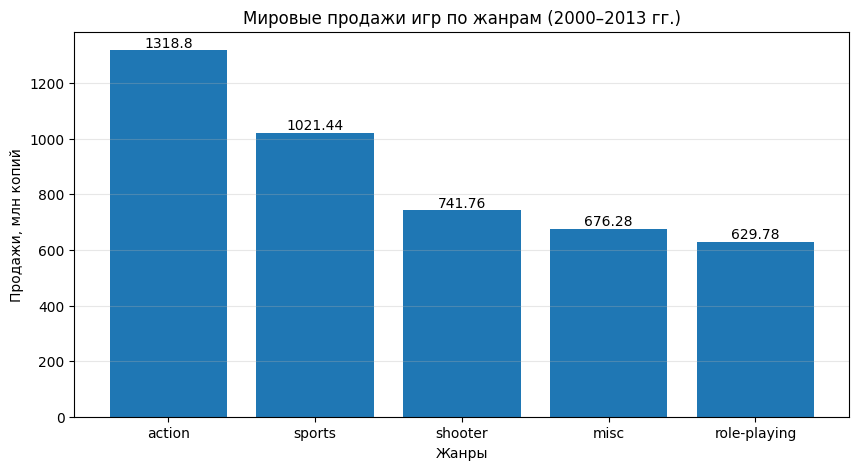

In [153]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    top_5_sales['genre'],
    top_5_sales['total_sales']
)

plt.title("Мировые продажи игр по жанрам (2000–2013 гг.)")
plt.xlabel('Жанры')
plt.ylabel("Продажи, млн копий")
plt.grid(axis='y', alpha=0.3 )
plt.bar_label(bars)

plt.show()

#### Вывод

Наибольший объём мировых продаж приходится на жанр Action. Жанр Sports занимает второе место, тогда как остальные жанры демонстрируют существенно меньший объём продаж.

---

### 5.4. Распределение продаж по регионам

In [172]:
region_sales = df_actual[
    ['na_sales','eu_sales','jp_sales','other_sales']
].sum()

name_column = {
    "na_sales": "Северная Америка",
    "eu_sales": "Европа",
    "jp_sales": "Япония",
    "other_sales": "Остальной мир"
}

region_sales = region_sales.rename(index=name_column)

region_sales
        

Северная Америка    3245.55
Европа              1811.77
Япония               722.67
Остальной мир        646.49
dtype: float64

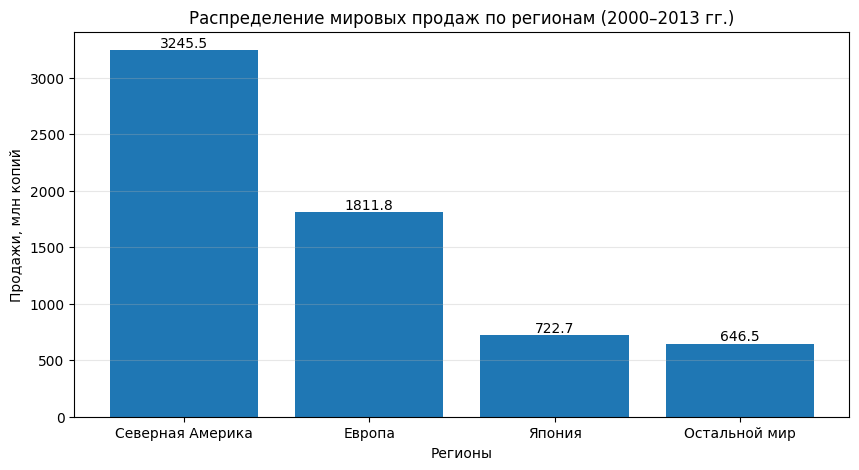

In [174]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    region_sales.index,
    region_sales.values.round(1)
)

plt.title("Распределение мировых продаж по регионам (2000–2013 гг.)")
plt.xlabel("Регионы")
plt.ylabel("Продажи, млн копий")
plt.grid(axis='y', alpha=0.3 )
plt.bar_label(bars)

plt.show()

### Вывод

Наибольший объём мировых продаж приходится на регион Северной Америки, который значительно опережает остальные рынки. Второе место занимает Европа, тогда как Япония и остальные регионы демонстрируют существенно меньший объём продаж. Это свидетельствует о том, что в период 2000–2013 гг. ключевыми рынками сбыта видеоигр являлись Северная Америка и Европа.

---

## 6. Итоговый вывод

В рамках проекта были подготовлены и проанализированы данные о рынке видеоигр за период 2000–2013 гг. В ходе предобработки были исправлены типы данных, устранены явные и неявные дубликаты, обработаны пропуски и сформирован актуальный набор данных для дальнейшего исследования.

Для расширения возможностей анализа были созданы категории пользовательских и критических оценок, а также рассчитан общий объём мировых продаж для каждой игры.

Исследование показало, что значительная часть игр не имеет пользовательских и критических оценок. Среди доступных оценок преобладают средние значения, тогда как низкие оценки встречаются значительно реже.

По количеству выпущенных игр лидируют платформы PS2 и DS. В число наиболее популярных также вошли Wii, PSP, Xbox 360, PS3 и GBA, что отражает лидирующие позиции как домашних, так и портативных игровых систем.

Среди игровых жанров по количеству выпущенных игр лидирует Action, за которым следуют Sports и Misc. При этом жанр Action также занимает первое место по объёму мировых продаж, значительно опережая остальные категории.

Анализ распределения продаж по регионам показал, что крупнейшим рынком видеоигр в рассматриваемый период являлась Северная Америка. Второе место занимает Европа, тогда как Япония и остальные регионы демонстрируют существенно меньший объём продаж.

В результате была выполнена предобработка данных и проведён исследовательский анализ, позволивший выявить ключевые особенности рынка видеоигр за период 2000–2013 гг.